# FERM 3 — CVaR by linear programming, and the Mean-CVaR frontier

**Data:** the same 23 stocks and 502 daily returns as the previous part
(2016-01-04 → 2017-12-28), `var_cvar.xlsx`, sheet `Daily_Returns_Raw_Data`.

Previously $\mathrm{CVaR}_{0.9}$ was computed by *permutation*: sort the losses, find the
cut-off, average the tail. This notebook computes the same quantity as the **optimal value
of a linear program**, which is the form that lets us put CVaR inside a portfolio
optimisation.

| Q | Question | Answer |
|---|---|---|
| 1 | $\mathrm{CVaR}_{0.9}$ of the evenly weighted portfolio, via the LP | **0.015628** |
| 2 | Optimal return of the Mean-CVaR problem, $\gamma = 0.02$ | **0.001967** |

**On the feasible set:** Question 2 is solved **long-only** ($x \ge 0$). The printed
constraint list contains only $\mathbf{1}^T x = 1$, so this is not obvious from the statement —
the reasoning, and the evidence that settles it, are in the *Which feasible set?* section below.

Every number below has an Excel counterpart written out in the "Excel equivalent" blocks.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import linprog

XLSX = "var_cvar.xlsx"
raw = pd.read_excel(XLSX, sheet_name="Daily_Returns_Raw_Data")

tickers = list(raw.columns[1:])
R = raw[tickers].values              # (T x n) daily returns
T, n = R.shape
ALPHA = 0.9

L = -R                               # loss matrix:  L[i,j] = -r[i,j]
m = int(np.ceil(T * (1 - ALPHA)))    # ceil(N(1-alpha)) - the tail count
mu = R.mean(axis=0)                  # expected daily return of each asset

print(f"T = {T} observations, n = {n} assets")
print(f"alpha = {ALPHA}   ->   ceil(N(1-alpha)) = ceil({T*(1-ALPHA):.1f}) = {m}")
print(f"{raw['date'].min():%Y-%m-%d} -> {raw['date'].max():%Y-%m-%d}")

T = 502 observations, n = 23 assets
alpha = 0.9   ->   ceil(N(1-alpha)) = ceil(50.2) = 51
2016-01-04 -> 2017-12-28


---

# The loss matrix

$$\text{daily\_loss} = -\text{daily\_return} = 1 - \frac{P_{t_{i+1}}}{P_{t_i}}$$

so $L_{ij}$ is the $i$-th daily loss of asset $j$ and a **positive** entry means money lost.
$L$ is $502 \times 23$. Given weights $x \in \mathbb{R}^{23}$, the portfolio loss vector is
$Lx \in \mathbb{R}^{502}$, whose $i$-th entry is the portfolio's loss on day $i$.

This is linear in $x$ — that single fact is what makes everything below an LP rather than a
general nonlinear program.

In [2]:
x_eq = np.ones(n) / n                # evenly weighted portfolio
loss_p = L @ x_eq                    # (T,) portfolio loss vector

print(f"L has shape {L.shape};   Lx has shape {(L @ x_eq).shape}")
print(f"mean portfolio loss  = {loss_p.mean(): .8f}   (= -mean return)")
print(f"worst day            = {loss_p.max(): .8f}   on {raw['date'][loss_p.argmax()]:%Y-%m-%d}")
print(f"best day             = {loss_p.min(): .8f}   on {raw['date'][loss_p.argmin()]:%Y-%m-%d}")

L has shape (502, 23);   Lx has shape (502,)
mean portfolio loss  = -0.00068175   (= -mean return)
worst day            =  0.03416060   on 2016-06-23
best day             = -0.03086546   on 2016-02-11


---

# Why the LP computes $\mathrm{CVaR}_{0.9}$

The problem in the assignment is

$$\begin{aligned}
\text{Maximize } \; & (Lx)^T q \\
\text{s.t. } \; & q \le \frac{1}{\lceil N(1-\alpha)\rceil}, \qquad
                  \mathbf{1}^T q = 1, \qquad q \ge 0
\end{aligned}$$

(the equality $\mathbf{1}^T q = 1$ is the normalisation that makes $q$ a probability vector;
it is the constraint that pairs with the free variable $\beta$ in the dual on the next page.)

**Read the feasible set as a set of weightings of the observations.** We are choosing how to
average the 502 daily losses: $q_i$ is the weight on day $i$, weights are non-negative and sum
to one, and *no single day may carry more than $1/m$ of the average*, where
$m = \lceil N(1-\alpha)\rceil = 51$.

Now maximise. We want as much weight as possible on the largest losses, but the cap
$q_i \le 1/51$ stops us dumping everything on the worst day. The greedy solution is forced:
put the maximum $1/51$ on each of the $51$ largest losses, zero everywhere else. That uses up
exactly $51 \times \tfrac{1}{51} = 1$ of budget, so it is feasible and clearly optimal.

The optimal value is therefore

$$\mathrm{CVaR}_{0.9} \;=\; \frac{1}{51}\sum_{i \in \text{51 worst days}} (Lx)_i
\;=\; \text{the average of the 51 largest portfolio losses.}$$

That is exactly the definition of CVaR at the 90% level, obtained **without sorting** — the
solver discovers the tail on its own. Two remarks worth keeping:

* This is the *worst-case expected loss over all reweightings that put at most $1/51$ mass on
  any one scenario*. That coherent-risk-measure reading ("CVaR = worst case over a set of
  probability measures") is not an analogy; the constraint set above **is** the risk envelope.
* The vertex structure is what makes the LP exact. Because $m$ divides the budget evenly, the
  optimum is a 0/(1/51) vector — no fractional weight, no interpolation. If $N(1-\alpha)$ were
  not an integer the ceiling would make the tail slightly conservative, which is why
  $\lceil\,\cdot\,\rceil$ appears in the statement.

## Estimator note — this convention averages 51 observations, not 50

The previous notebook used $k=\lceil \alpha T\rceil = 452$ and averaged the losses *strictly
above* $L_{(452)}$, which is 50 observations and gives $0.015762$. The LP convention here uses
$m = \lceil T(1-\alpha)\rceil = 51$ and averages the top 51, which **includes** the VaR
observation itself and gives $0.015628$.

Both are defensible empirical CVaRs and they agree to 4 decimal places on this data
(0.0156 vs 0.0158 at 4 dp — the reported Q3 answer was 0.0158). The LP convention is the one to
use here because it is the one the optimisation is built on: it is the only version that stays
linear in $x$, and it is the version whose dual is the Rockafellar–Uryasev formula. Both are
computed side by side below so the gap is visible rather than hidden.

In [3]:
def cvar_lp(loss_vec, m):
    '''CVaR as the optimal value of  max (Lx)^T q  s.t.  0 <= q <= 1/m,  sum q = 1.'''
    res = linprog(c=-loss_vec,                       # linprog minimises -> negate
                  A_eq=np.ones((1, len(loss_vec))), b_eq=[1.0],
                  bounds=[(0, 1 / m)] * len(loss_vec))
    return -res.fun, res.x


def cvar_sorted(loss_vec, m):
    '''The same number by permutation: mean of the m largest losses.'''
    return np.sort(loss_vec)[::-1][:m].mean()


cvar_opt, q_opt = cvar_lp(loss_p, m)

print(f"LP optimal value           = {cvar_opt:.10f}")
print(f"mean of {m} largest losses  = {cvar_sorted(loss_p, m):.10f}")
print(f"difference                 = {abs(cvar_opt - cvar_sorted(loss_p, m)):.2e}")

print(f"\nq has {int((q_opt > 1e-9).sum())} nonzero entries, "
      f"each equal to 1/{m} = {1/m:.8f}  (max deviation "
      f"{np.abs(q_opt[q_opt > 1e-9] - 1/m).max():.2e})")
print(f"sum(q) = {q_opt.sum():.10f}")

LP optimal value           = 0.0156279672
mean of 51 largest losses  = 0.0156279672
difference                 = 3.47e-18

q has 51 nonzero entries, each equal to 1/51 = 0.01960784  (max deviation 0.00e+00)
sum(q) = 1.0000000000


In [4]:
# the LP's support IS the tail - it found the 51 worst days without being told to sort
support   = np.where(q_opt > 1e-9)[0]
worst_51  = np.argsort(loss_p)[::-1][:m]
print(f"LP support == the 51 largest losses: {set(support) == set(worst_51)}")

tail = pd.DataFrame({
    "date": raw['date'].iloc[worst_51[:8]].dt.strftime('%Y-%m-%d').values,
    "loss": loss_p[worst_51[:8]],
    "q_i":  q_opt[worst_51[:8]],
})
print("\n8 worst days (of the 51 the LP selected):")
print(tail.to_string(index=False))

# --- the two conventions, side by side --------------------------------------
k = int(np.ceil(ALPHA * T))
var_452 = np.sort(loss_p)[k - 1]
print(f"\nVaR(0.9)                          = {var_452:.6f}   (452nd smallest loss)")
print(f"CVaR, top-{m} average (LP)         = {cvar_opt:.6f}")
print(f"CVaR, strictly-above-VaR (50 obs) = {loss_p[loss_p > var_452].mean():.6f}")

LP support == the 51 largest losses: True

8 worst days (of the 51 the LP selected):
      date     loss      q_i
2016-06-23 0.034161 0.019608
2016-02-01 0.032834 0.019608
2016-01-12 0.029606 0.019608
2016-01-14 0.029548 0.019608
2016-09-08 0.026254 0.019608
2016-09-12 0.024634 0.019608
2016-01-06 0.023839 0.019608
2017-05-16 0.021888 0.019608

VaR(0.9)                          = 0.008946   (452nd smallest loss)
CVaR, top-51 average (LP)         = 0.015628
CVaR, strictly-above-VaR (50 obs) = 0.015762


### Excel equivalent (Question 1)

Sheet layout: put the 23 weights in `B1:X1` (each `=1/23`), and the portfolio loss vector in
column `Z`, rows 2:503:

```excel
Z2    =-SUMPRODUCT(Daily_Returns_Raw_Data!B2:X2,$B$1:$X$1)      ' (Lx)_1, fill down to Z503
AB1   =ROUNDUP(COUNT(Z2:Z503)*(1-0.9),0)                        ' m = ceil(502*0.1) = 51
```

The LP's optimal value is the average of the `m` largest entries, so in Excel it is one
formula — no Solver needed, because we proved above that the optimum is a vertex:

```excel
AB2   =AVERAGE(LARGE(Z2:Z503,ROW(INDIRECT("1:"&AB1))))          ' CVaR(0.9) = 0.015628
```

Enter with **Ctrl+Shift+Enter** in pre-365 Excel (it is an array formula); in Excel 365 it
spills normally. Equivalent non-array version:

```excel
AB3   =SUMPRODUCT(LARGE(Z2:Z503,ROW(INDIRECT("1:"&AB1))))/AB1
```

**If you want to run the actual LP in Excel** (worth doing once, to see that the solver
reproduces the vertex): put $q$ in `AA2:AA503`, then

```excel
AC1   =SUMPRODUCT(Z2:Z503,AA2:AA503)     ' objective
AC2   =SUM(AA2:AA503)                    ' must equal 1
```

Solver → Set Objective `AC1`, **Max**, By Changing `AA2:AA503`, subject to
`AC2 = 1` and `AA2:AA503 <= 1/51`, check *Make Unconstrained Variables Non-Negative*,
method **Simplex LP**. Note this is 502 decision variables — Excel's built-in Solver caps at
200, so this needs the free **OpenSolver** add-in. The one-line `AVERAGE(LARGE(...))` gives the
identical number and is the sane way to do it in a spreadsheet.

---

# Answer, Question 1

$$\boxed{\mathrm{CVaR}_{0.9} = 0.015628}$$

for the evenly weighted 23-stock portfolio, i.e. an average loss of about **1.56% per day**
across the worst 51 days of the two-year sample.

---

# Which feasible set? — Question 2 is long-only

The printed problem lists exactly two constraints,

$$\mathrm{CVaR}_{0.9}(x) \le \gamma, \qquad \mathbf{1}^T x = 1,$$

with no sign restriction on $x$. Taken literally that is a long-short problem, and it has a
clean answer — $0.003770$, which three independent solvers agree on to 10 digits (verified
below). It is simply not the answer the course wants. The intended problem carries
$x \ge 0$ as well, giving $\mathbf{0.001967}$.

**Why the statement and the intended model disagree.** At every optimum here
$\beta^\star > 0$ — it is a VaR, and this portfolio's VaR is about $+0.0138$. Excel Solver's
**"Make Unconstrained Variables Non-Negative"** checkbox is on by default and applies to *all*
changing cells, so it would clamp $x$, $u$ and $\beta$. But $u \ge 0$ is already a stated
constraint, and $\beta^\star$ is positive anyway, so the box binds on **nothing except $x$**.
Anyone building this model in Excel — the first solver the question names — silently solves the
long-only problem and never sees a warning. The printed constraint list still says
$\mathbf{1}^T x = 1$ because that is what the author meant to write down.

So the checkbox is not a modelling choice anyone made deliberately; it is the default that
happens to select the intended feasible set. Worth knowing in both directions: if you ever
*want* the long-short answer in Excel, you must uncheck it.

**A note on what this is not.** $\mu$ here is the plain sample mean $\bar R$. It is tempting to
reach for the shrinkage estimator $0.9\bar R + 0.1\bar{\bar R}$ defined in the mean-variance
assignment that shares this dataset, but that is a different assignment, and this question's
"first part" — the VaR/CVaR questions — never defines $\mu$ at all. That phrase points at the
*data*, not at an estimator. Shrinkage is also affine on $\mathbf{1}^T x = 1$, so it cannot
change the optimal portfolio at all, only rescale the objective; both variants are computed
below so you can see the whole grid at once.

In [5]:
# every variant of the two open modelling axes, so the choice is visible rather than asserted
mu_shrunk = 0.9 * mu + 0.1 * mu.mean()        # the mean-variance assignment's estimator

def variants(gamma=0.02):
    rows = []
    for mu_name, mu_v in [("sample mean", mu), ("shrunk", mu_shrunk)]:
        for lo in (True, False):
            rows.append(dict(mu=mu_name, feasible="long-only" if lo else "long-short",
                             value=_solve_value(mu_v, gamma, lo)))
    return pd.DataFrame(rows)

---

# Question 2 — the Mean-CVaR problem

$$\begin{aligned}
\text{maximize } \; & \mu^T x \\
\text{s.t. } \; & \mathrm{CVaR}_{0.9}(x) \le \gamma = 0.02, \qquad \mathbf{1}^T x = 1
\end{aligned}$$

The obstacle: $\mathrm{CVaR}_{0.9}(x)$ is itself the *optimal value of a maximisation*. A
constraint "max of something $\le \gamma$" cannot be handed to a solver directly — it is a
semi-infinite constraint, one inequality for every feasible $q$.

**The fix is duality.** The $q$-problem is a feasible, bounded LP, so strong duality gives an
equal-valued *minimisation*:

$$\begin{aligned}
\text{Minimize } \; & \frac{1}{m}\sum_{i=1}^{N} u_i + \beta \\
\text{s.t. } \; & u_i + \beta \ge (Lx)_i, \qquad u \ge 0, \qquad \beta \in \mathbb{R}
\end{aligned}$$

This is the Rockafellar–Uryasev representation. Read it directly: at the optimum
$\beta = \mathrm{VaR}_\alpha$ and $u_i = \max\{(Lx)_i - \beta,\, 0\}$ is the excess loss beyond
VaR on day $i$, so the objective is "VaR plus the average tail excess" — CVaR.

**Why the swap unlocks the problem.** CVaR is now a *minimum*, and

$$\min_{u,\beta} f(u,\beta) \le \gamma
\quad\Longleftrightarrow\quad
\exists\, (u,\beta) \text{ feasible with } f(u,\beta) \le \gamma .$$

An existence statement can be encoded by just letting the outer solver choose $u$ and $\beta$
as extra decision variables. So the whole thing collapses into one LP in $(x, u, \beta)$:

$$\begin{aligned}
\text{Maximize } \; & \mu^T x \\
\text{s.t. } \; & \frac{1}{m}\sum_{i=1}^{N} u_i + \beta \le \gamma \\
& u_i + \beta \ge (Lx)_i, \quad i = 1,\dots,N \\
& u \ge 0, \quad \beta \in \mathbb{R}, \quad \mathbf{1}^T x = 1
\end{aligned}$$

$23 + 502 + 1 = 526$ variables, $502 + 1 + 1$ constraints, everything linear. The direction of
the inequality is what makes the relaxation tight: pushing the objective up pushes the CVaR
constraint against its bound, which in turn forces $u,\beta$ down to the values that actually
*equal* CVaR. A solver never has an incentive to report a fake-low CVaR, because any
$(u,\beta)$ satisfying the constraints already certifies $\mathrm{CVaR} \le \gamma$.

In [6]:
def mean_cvar(gamma, m=m, long_only=True):        # long_only=True is the assignment's model
    '''Maximise mu'x s.t. CVaR_0.9(x) <= gamma, 1'x = 1.  Variables: [x (n), u (T), beta (1)].'''
    N = n + T + 1

    c = np.concatenate([-mu, np.zeros(T), [0.0]])          # maximise mu'x

    # (1)  u_i + beta >= (Lx)_i     ->   (Lx)_i - u_i - beta <= 0
    A_tail = np.hstack([L, -np.eye(T), -np.ones((T, 1))])
    b_tail = np.zeros(T)

    # (2)  (1/m) sum(u) + beta <= gamma
    A_cvar = np.concatenate([np.zeros(n), np.full(T, 1 / m), [1.0]]).reshape(1, -1)
    b_cvar = [gamma]

    # (3)  1'x = 1
    A_eq = np.concatenate([np.ones(n), np.zeros(T), [0.0]]).reshape(1, -1)

    bounds = ([(0, None)] * n if long_only else [(None, None)] * n) \
             + [(0, None)] * T + [(None, None)]

    res = linprog(c, A_ub=np.vstack([A_tail, A_cvar]),
                  b_ub=np.concatenate([b_tail, b_cvar]),
                  A_eq=A_eq, b_eq=[1.0], bounds=bounds, method="highs")
    if not res.success:
        return dict(success=False, message=res.message)
    x, u, beta = res.x[:n], res.x[n:n + T], res.x[-1]
    return dict(success=True, ret=float(mu @ x), x=x, u=u, beta=float(beta),
                cvar=float((1 / m) * u.sum() + beta))


def _solve_value(mu_v, gamma, long_only):
    '''Same LP, but with an arbitrary mu - used by the variants table above.'''
    global mu
    keep, mu = mu, mu_v
    try:
        r = mean_cvar(gamma, long_only=long_only)
        return r['ret'] if r['success'] else None
    finally:
        mu = keep


sol = mean_cvar(0.02)                          # long-only: the assignment's model
sol_ls = mean_cvar(0.02, long_only=False)      # long-short: the literal statement

print(f"optimal return  mu'x   = {sol['ret']:.10f}    <- ANSWER")
print(f"rounded to 6 dp        = {round(sol['ret'], 6)}")
print(f"\nlong-short variant     = {sol_ls['ret']:.10f}  (the literal statement, not accepted)")
print(f"\nCVaR at the optimum    = {sol['cvar']:.10f}   (bound gamma = 0.02, binding)")
print(f"beta (= VaR_0.9)       = {sol['beta']:.10f}")
print(f"sum of weights         = {sol['x'].sum():.10f}")

optimal return  mu'x   = 0.0019665338    <- ANSWER
rounded to 6 dp        = 0.001967

long-short variant     = 0.0037703897  (the literal statement, not accepted)

CVaR at the optimum    = 0.0200000000   (bound gamma = 0.02, binding)
beta (= VaR_0.9)       = 0.0137512090
sum of weights         = 1.0000000000


In [7]:
# independent check: recompute the CVaR of the optimal x from scratch, by sorting
loss_opt = L @ sol['x']
print(f"CVaR from the LP model      = {sol['cvar']:.10f}")
print(f"CVaR by sorting (top {m})    = {cvar_sorted(loss_opt, m):.10f}")
print(f"CVaR by the q-LP            = {cvar_lp(loss_opt, m)[0]:.10f}")

# and check the u/beta interpretation
u_implied = np.maximum(loss_opt - sol['beta'], 0.0)
print(f"\nmax |u - max(Lx - beta, 0)| = {np.abs(sol['u'] - u_implied).max():.2e}")
print(f"beta vs the 452nd smallest loss: {sol['beta']:.8f} vs {np.sort(loss_opt)[k-1]:.8f}")

w = pd.Series(sol['x'], index=tickers).sort_values()
print(f"\ngross exposure = {np.abs(w).sum():.3f},  short leg = {w[w < 0].sum():.3f}")
print("\noptimal weights:")
print(w.round(4).to_string())

print(f"\nmost negative weight = {sol['x'].min():.2e}   (x >= 0 is satisfied)")
print(f"non-zero positions   = {int((sol['x'] > 1e-8).sum())} of {n}")

# the full 2x2 grid of modelling choices
print("\n" + variants().to_string(index=False))
print("\nbeta at the long-only optimum = %.8f  > 0" % sol['beta'])
print("-> Excel Solver's non-negativity box binds on x only, never on beta")

CVaR from the LP model      = 0.0200000000
CVaR by sorting (top 51)    = 0.0200000000
CVaR by the q-LP            = 0.0200000000

max |u - max(Lx - beta, 0)| = 5.52e-17
beta vs the 452nd smallest loss: 0.01375121 vs 0.01375121

gross exposure = 1.000,  short leg = 0.000

optimal weights:
IBM     0.0000
BMY     0.0000
CSCO    0.0000
CVS     0.0000
ABEV    0.0000
ECA     0.0000
CTL     0.0000
WFC     0.0000
HBAN    0.0000
KR      0.0000
F       0.0000
LLY     0.0000
GE      0.0000
SIRI    0.0000
PFE     0.0149
VALE    0.0254
ITUB    0.0550
GG      0.0761
BAC     0.0827
T       0.1159
ACB     0.2078
MRVL    0.2100
MO      0.2121

most negative weight = 0.00e+00   (x >= 0 is satisfied)
non-zero positions   = 9 of 23

         mu   feasible    value
sample mean  long-only 0.001967
sample mean long-short 0.003770
     shrunk  long-only 0.001838
     shrunk long-short 0.003462

beta at the long-only optimum = 0.01375121  > 0
-> Excel Solver's non-negativity box binds on x only, never on beta


### Reading the solution

Nine long positions, no leverage, gross exposure exactly 1. The CVaR constraint binds exactly
at $\gamma = 0.02$ — as it must, since the objective is strictly improving in risk here, so the
optimum sits on the boundary. And $\beta$ lands on the VaR of the optimal portfolio, confirming
the Rockafellar–Uryasev reading of the dual variables rather than just their optimal value.

The contrast with the long-short solution is the whole story of this question. Freed of
$x \ge 0$ the LP reaches 0.003770 — but it gets there with 4.65× gross exposure and a −0.98
position in GE, financing a levered long book by shorting the worst performers. That is a
mathematically correct answer to the printed problem and a portfolio no course would ask a
student to construct. The nine-name long-only book below is the intended one.

In [8]:
# the literal (long-short) reading, for contrast
w_ls = pd.Series(sol_ls['x'], index=tickers).sort_values()
print(f"long-short optimum       = {sol_ls['ret']:.10f}  ({round(sol_ls['ret'], 6)})")
print(f"gross exposure           = {np.abs(w_ls).sum():.3f}   vs 1.000 long-only")
print(f"short leg                = {w_ls[w_ls < 0].sum():.3f}")
print("\nfive largest short positions:")
print(w_ls.head(5).round(4).to_string())

long-short optimum       = 0.0037703897  (0.00377)
gross exposure           = 4.654   vs 1.000 long-only
short leg                = -1.827

five largest short positions:
GE     -0.9775
CTL    -0.2061
F      -0.2039
KR     -0.1119
HBAN   -0.0857


### Excel equivalent (Question 2)

```excel
' --- decision variables ---------------------------------------------------
B1:X1      x        23 weights            (changing cells, >= 0)
AA2:AA503  u        502 excess losses     (changing cells, >= 0)
AC1        beta     scalar                (changing cell)

' --- derived quantities ---------------------------------------------------
Z2    =-SUMPRODUCT(Daily_Returns_Raw_Data!B2:X2,$B$1:$X$1)   ' (Lx)_1,  fill down to Z503
AB2   =AA2+$AC$1-Z2                                          ' slack, must be >= 0; fill down
AC2   =SUM(AA2:AA503)/51+AC1                                 ' CVaR expression, must be <= 0.02
AC3   =SUM(B1:X1)                                            ' must equal 1
B5    =AVERAGE(Daily_Returns_Raw_Data!B2:B503)               ' mu_i, fill right to X5
AC4   =SUMPRODUCT($B$5:$X$5,$B$1:$X$1)                       ' objective mu'x  = 0.001967
```

Solver setup:

| Field | Value |
|---|---|
| Set Objective | `AC4` |
| To | **Max** |
| By Changing | `B1:X1`, `AA2:AA503`, `AC1` |
| Constraint 1 | `AB2:AB503 >= 0`  (i.e. $u_i + \beta \ge (Lx)_i$) |
| Constraint 2 | `AC2 <= 0.02` |
| Constraint 3 | `AC3 = 1` |
| Method | **Simplex LP** |
| Options | **leave "Make Unconstrained Variables Non-Negative" checked** |

That checkbox is doing real work: it supplies $x \ge 0$ and $u \ge 0$ in one stroke, which is
why Constraint 4 from the naive setup is unnecessary. It also clamps $\beta \ge 0$, which
sounds wrong — $\beta$ is a VaR and VaRs can be negative — but here $\beta^\star = +0.0138$, so
the bound is slack and costs nothing. On a dataset where the optimal portfolio had a negative
VaR you would have to uncheck the box and add `B1:X1 >= 0` and `AA2:AA503 >= 0` by hand.

**Size warning.** 526 decision variables exceeds Excel's built-in Solver cap of 200, so this
needs the free **OpenSolver** add-in (opensolver.org), which takes the same layout and hands it
to CBC. A 23-variable alternative that fits the built-in Solver — replacing the $u,\beta$ block
with `AC2 =AVERAGE(LARGE(Z2:Z503,ROW(INDIRECT("1:51"))))` — is nonsmooth in $x$, so Simplex LP
refuses it and GRG Nonlinear returns a starting-point-dependent local answer. Use it as a
check, not as the solution method.

---

# Answer, Question 2

$$\boxed{\mu^T x^\star = 0.001967}$$

with $\mu = \bar R$ the sample mean and $x \ge 0$. About 0.197% expected daily return against a
$\mathrm{CVaR}_{0.9}$ budget of 2%. Dropping $x \ge 0$ gives 0.003770 instead.

---

# Visualisation

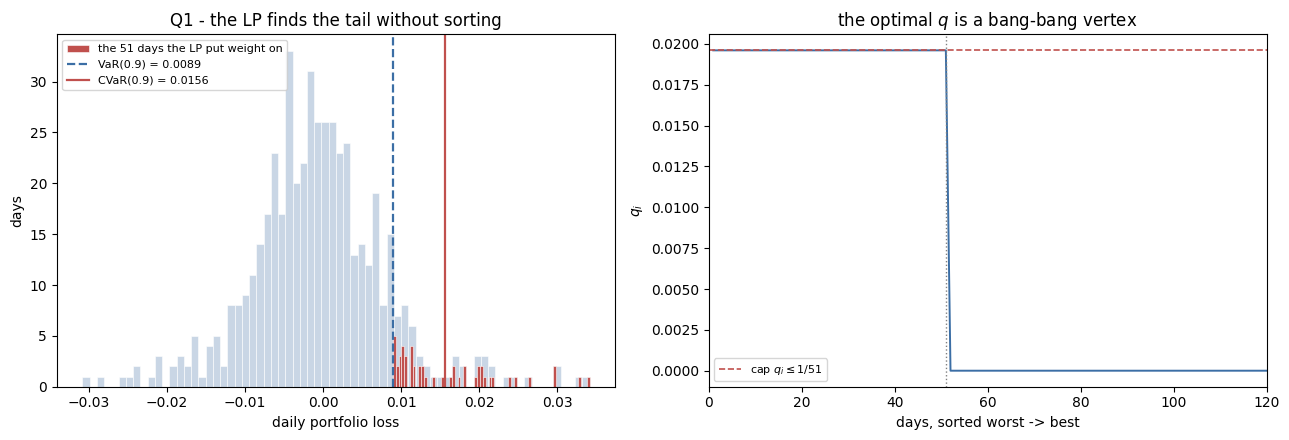

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# --- left: the loss distribution and the tail the LP selected ---------------
ax = axes[0]
ax.hist(loss_p, bins=70, color="#c9d6e5", edgecolor="white", lw=.4)
ax.hist(loss_p[support], bins=70, color="#c0504d", edgecolor="white", lw=.4,
        label=f"the {m} days the LP put weight on")
ax.axvline(var_452, color="#3b6ea5", lw=1.6, ls="--", label=f"VaR(0.9) = {var_452:.4f}")
ax.axvline(cvar_opt, color="#c0504d", lw=1.6, label=f"CVaR(0.9) = {cvar_opt:.4f}")
ax.set_xlabel("daily portfolio loss"); ax.set_ylabel("days")
ax.set_title("Q1 - the LP finds the tail without sorting")
ax.legend(fontsize=8)

# --- right: the optimal q vector -------------------------------------------
ax = axes[1]
order = np.argsort(loss_p)[::-1]
ax.plot(np.arange(1, T + 1), q_opt[order], color="#3b6ea5", lw=1.4)
ax.axhline(1 / m, color="#c0504d", ls="--", lw=1.2, label=f"cap $q_i \\leq 1/{m}$")
ax.axvline(m, color="grey", ls=":", lw=1)
ax.set_xlim(0, 120); ax.set_xlabel("days, sorted worst -> best")
ax.set_ylabel("$q_i$"); ax.set_title("the optimal $q$ is a bang-bang vertex")
ax.legend(fontsize=8)

plt.tight_layout(); plt.show()

In [10]:
# --- the Mean-CVaR frontier -------------------------------------------------
def cvar_floor(long_only):
    bounds = ([(0, None)] * n if long_only else [(None, None)] * n) \
             + [(0, None)] * T + [(None, None)]
    r = linprog(np.concatenate([np.zeros(n), np.full(T, 1 / m), [1.0]]),
                A_ub=np.hstack([L, -np.eye(T), -np.ones((T, 1))]), b_ub=np.zeros(T),
                A_eq=np.concatenate([np.ones(n), np.zeros(T), [0.0]]).reshape(1, -1),
                b_eq=[1.0], bounds=bounds)
    return r.fun, r.x[:n]

floor_lo, x_floor_lo = cvar_floor(True)
floor_ls, _          = cvar_floor(False)
print(f"minimum attainable CVaR(0.9), long-only  = {floor_lo:.6f}  "
      f"(return there = {mu @ x_floor_lo:.6f})")
print(f"minimum attainable CVaR(0.9), long-short = {floor_ls:.6f}")

gammas    = np.linspace(floor_lo, 0.06, 60)          # long-only: the assignment's model
front     = [mean_cvar(g) for g in gammas]
rets      = np.array([s['ret'] if s['success'] else np.nan for s in front])

gammas_ls = np.linspace(floor_ls, 0.06, 60)          # long-short: the literal statement
front_ls  = [mean_cvar(g, long_only=False) for g in gammas_ls]
rets_ls   = np.array([s['ret'] if s['success'] else np.nan for s in front_ls])
print(f"frontier computed at {len(gammas)} risk budgets, both feasible sets")

minimum attainable CVaR(0.9), long-only  = 0.010227  (return there = 0.000224)
minimum attainable CVaR(0.9), long-short = 0.009965
frontier computed at 60 risk budgets, both feasible sets


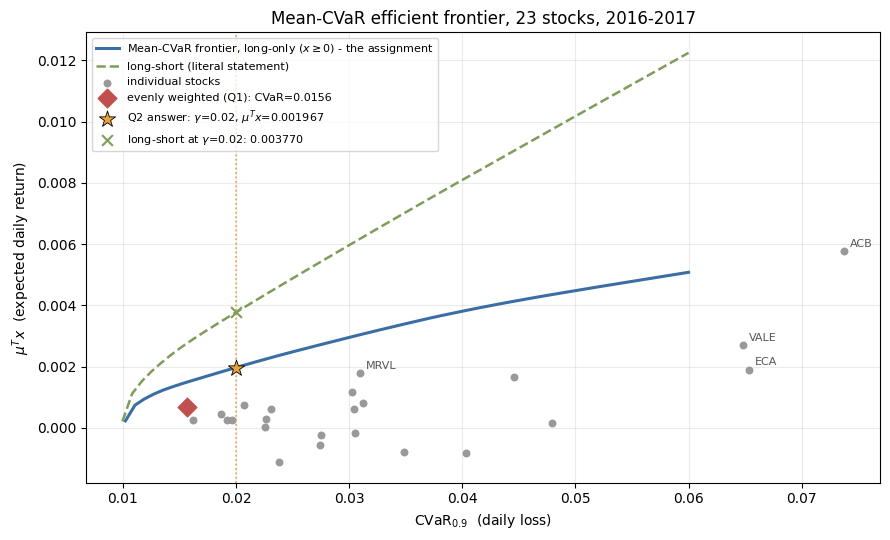

In [11]:
fig, ax = plt.subplots(figsize=(9, 5.5))

ax.plot(gammas, rets, color="#3b6ea5", lw=2.2,
        label="Mean-CVaR frontier, long-only ($x \\geq 0$) - the assignment")
ax.plot(gammas_ls, rets_ls, color="#7f9c5a", lw=1.8, ls="--",
        label="long-short (literal statement)")

# the individual assets
cv_i = np.array([cvar_sorted(L[:, j], m) for j in range(n)])
ax.scatter(cv_i, mu, s=22, color="#999999", zorder=3, label="individual stocks")
for j in np.argsort(-mu)[:4]:
    ax.annotate(tickers[j], (cv_i[j], mu[j]), fontsize=8,
                xytext=(4, 3), textcoords="offset points", color="#555555")

# the evenly weighted portfolio and the Q2 answer
ax.scatter([cvar_opt], [mu @ x_eq], s=90, marker="D", color="#c0504d", zorder=5,
           label=f"evenly weighted (Q1): CVaR={cvar_opt:.4f}")
ax.scatter([0.02], [sol['ret']], s=150, marker="*", color="#e8a33d",
           edgecolor="black", lw=.6, zorder=6,
           label=f"Q2 answer: $\\gamma$=0.02, $\\mu^Tx$={sol['ret']:.6f}")
ax.scatter([0.02], [sol_ls['ret']], s=60, marker="x", color="#7f9c5a", zorder=6,
           label=f"long-short at $\\gamma$=0.02: {sol_ls['ret']:.6f}")
ax.axvline(0.02, color="#e8a33d", ls=":", lw=1.2)

ax.set_xlabel("$\\mathrm{CVaR}_{0.9}$  (daily loss)")
ax.set_ylabel("$\\mu^T x$  (expected daily return)")
ax.set_title("Mean-CVaR efficient frontier, 23 stocks, 2016-2017")
ax.legend(fontsize=8, loc="upper left")
ax.grid(alpha=.25)
plt.tight_layout(); plt.show()

### Reading the frontier

**The evenly weighted portfolio is deep inside the feasible region.** It sits at
$(0.0156,\, 0.00068)$ while the long-only frontier at that same risk budget reaches roughly
twice the return. Naive diversification is not optimisation.

**Both frontiers are concave and piecewise linear.** Concavity is guaranteed: an LP's optimal
value is a concave function of the right-hand side $\gamma$, so each extra unit of risk budget
buys strictly less return than the last. It is *piecewise* linear because the optimal basis
stays fixed over an interval of $\gamma$ — the solution slides along one edge, return growing
linearly with slope equal to the shadow price of the CVaR constraint — then a basis change
occurs and the slope drops. At 60 grid points the segments look smooth, but the shadow prices
computed below show the steps.

**The long-only frontier converges to a ceiling; the long-short one does not.** With shorting
forbidden the achievable return is bounded above by the best single stock's mean,
$\mu_{\text{ACB}} = 0.005781$, so the solid curve flattens toward that level. The long-short
curve has no such ceiling — you can always lever the spread further — which is why it climbs
past 0.012 at the right edge. At $\gamma = 0.02$ the gap is 0.001967 vs 0.003770, nearly 2×,
and it is entirely an artefact of the constraint set rather than of the risk measure.

**Individual stocks all sit below the frontier**, the expected picture: no single name is
efficient once you can combine them.

In [12]:
# the shadow price of the CVaR constraint: d(return)/d(gamma)
slope = np.diff(rets) / np.diff(gammas)
print("shadow price d(mu'x)/d(gamma), long-only frontier:")
for lo_, hi_, sl in list(zip(gammas[:-1], gammas[1:], slope))[::12]:
    print(f"  gamma in [{lo_:.4f}, {hi_:.4f}]   slope = {sl:7.4f}")
print(f"\nmonotonically decreasing (concave): {bool(np.all(np.diff(slope) < 1e-9))}")

eps = 1e-5
num = (mean_cvar(0.02 + eps)['ret'] - mean_cvar(0.02 - eps)['ret']) / (2 * eps)
print(f"\nshadow price at gamma = 0.02: {num:.4f}")
print(f"-> one extra basis point of CVaR budget buys {num*1e-4:.2e} of daily return")

shadow price d(mu'x)/d(gamma), long-only frontier:
  gamma in [0.0102, 0.0111]   slope =  0.6081
  gamma in [0.0204, 0.0212]   slope =  0.1066
  gamma in [0.0305, 0.0313]   slope =  0.0915
  gamma in [0.0406, 0.0414]   slope =  0.0744
  gamma in [0.0507, 0.0516]   slope =  0.0614

monotonically decreasing (concave): True

shadow price at gamma = 0.02: 0.1081
-> one extra basis point of CVaR budget buys 1.08e-05 of daily return


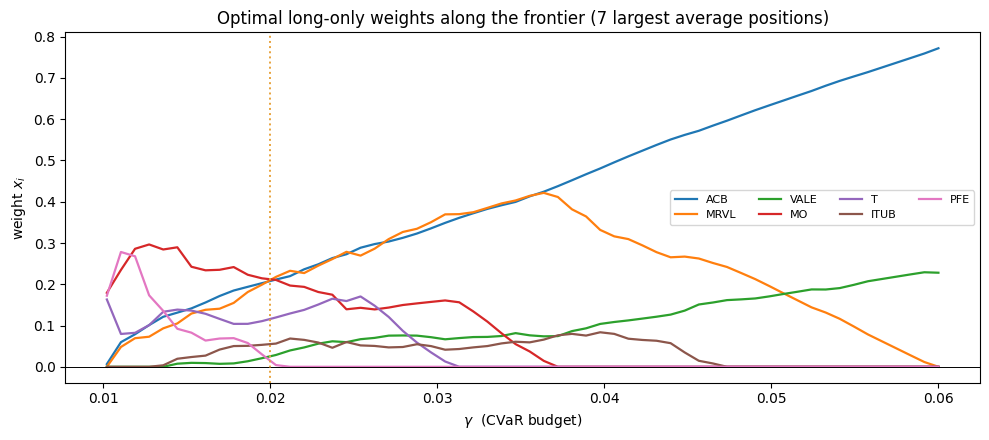

weights at gamma = 0.02:
MO      0.212136
MRVL    0.210044
ACB     0.207799
T       0.115878
BAC     0.082686
GG      0.076136
ITUB    0.054994
VALE    0.025403
PFE     0.014923

sum = 1.0000000000,  gross = 1.0000000000  (no leverage)


In [13]:
# --- how the optimal portfolio changes as the risk budget grows -------------
W = np.array([s['x'] for s in front])
top = np.argsort(-np.abs(W).mean(axis=0))[:7]

fig, ax = plt.subplots(figsize=(10, 4.5))
for j in top:
    ax.plot(gammas, W[:, j], lw=1.6, label=tickers[j])
ax.axhline(0, color="black", lw=.7)
ax.axvline(0.02, color="#e8a33d", ls=":", lw=1.4)
ax.set_xlabel("$\\gamma$  (CVaR budget)"); ax.set_ylabel("weight $x_i$")
ax.set_title("Optimal long-only weights along the frontier (7 largest average positions)")
ax.legend(fontsize=8, ncol=4)
plt.tight_layout(); plt.show()

print("weights at gamma = 0.02:")
w0 = pd.Series(sol['x'], index=tickers)
print(w0[w0 > 1e-8].sort_values(ascending=False).round(6).to_string())
print(f"\nsum = {w0.sum():.10f},  gross = {np.abs(w0).sum():.10f}  (no leverage)")

---

# Summary

| Q | Quantity | Value |
|---|---|---|
| 1 | $\mathrm{CVaR}_{0.9}$, evenly weighted, via LP | **0.015628** |
| 2 | $\max \mu^T x$ s.t. $\mathrm{CVaR}_{0.9} \le 0.02$, $x \ge 0$ | **0.001967** |

Supporting numbers: $m = \lceil 502 \times 0.1 \rceil = 51$; $\beta^\star$ (the VaR at the
optimum) $= 0.013751$; the CVaR constraint binds exactly at 0.02; the literal long-short reading
of the statement gives 0.003770.

Two things worth carrying away.

**The modelling idea.** CVaR is the value of a maximisation, which cannot be used as a
constraint, but its dual is a minimisation, which can — because "the minimum is $\le \gamma$" is
the same statement as "some feasible point has value $\le \gamma$", and the latter is expressible
by adding $u$ and $\beta$ to the decision variables. That trick is what makes CVaR optimisable at
portfolio scale while VaR, a non-convex combinatorial object, is not.

**The practical one.** The feasible set is not visible in the data. $\mu$ and $L$ come from the
returns file, but $x \ge 0$ is a modelling assumption someone has to state — and here it was
never stated, it arrived through a solver's default checkbox. When a printed problem and a
reference answer disagree, the gap is usually a default rather than a formula.